### Задание 1. Загрузка данных

Подключение библиотек

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Загрузка датасета

In [4]:
df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Задание 2. Знакомство с датасетом

Количество строк и столбцов

In [15]:
print(f"Строк: {df.shape[0]}")
print(f"Столбцов: {df.shape[1]}")

Строк: 891
Столбцов: 13


Названия всех столбцов

In [16]:
print(df.columns.tolist())

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'AgeGroup']


Типы данных столбцов

In [17]:
print(df.dtypes)

PassengerId       int64
Survived          int64
Pclass            int64
Name             object
Sex              object
Age             float64
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
Cabin            object
Embarked         object
AgeGroup       category
dtype: object


### Задание 3. Анализ пассажиров

Количество пассажиров каждого класса

In [40]:
print(df['Pclass'].value_counts().sort_index())

Pclass
1    216
2    184
3    491
Name: count, dtype: int64


Количество мужчин и женщин

In [19]:
print(df['Sex'].value_counts())

Sex
male      577
female    314
Name: count, dtype: int64


Разделение на возрастные группы

In [20]:
bins = [0, 12, 18, 35, 60, 100]
labels = ['Дети', 'Подростки', 'Взрослые', 'Средний возраст', 'Пожилые']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)
print(df['AgeGroup'].value_counts().sort_index())

AgeGroup
Дети                68
Подростки           45
Взрослые           366
Средний возраст    209
Пожилые             26
Name: count, dtype: int64


Средний возраст пассажиров

In [21]:
print(f"Средний возраст: {df['Age'].mean():.2f}")

Средний возраст: 29.70


Медианный возраст

In [22]:
print(f"Медианный возраст: {df['Age'].median():.2f}")

Медианный возраст: 28.00


Средняя стоимость билета

In [23]:
print(f"Средняя стоимость: {df['Fare'].mean():.2f}")

Средняя стоимость: 32.20


### Задание 4. Сравнение пассажиров разных классов

Средняя стоимость билета по классам

In [24]:
print(df.groupby('Pclass')['Fare'].mean().round(2))

Pclass
1    84.15
2    20.66
3    13.68
Name: Fare, dtype: float64


Средний возраст по классам

In [25]:
print(df.groupby('Pclass')['Age'].mean().round(2))

Pclass
1    38.23
2    29.88
3    25.14
Name: Age, dtype: float64


Количество мужчин и женщин в каждом классе

In [26]:
print(pd.crosstab(df['Pclass'], df['Sex']))

Sex     female  male
Pclass              
1           94   122
2           76   108
3          144   347


Класс с наибольшим количеством пассажиров

In [27]:
print(f"Самый многочисленный класс: {df['Pclass'].value_counts().idxmax()}")

Самый многочисленный класс: 3


Вывод:
- 1 класс: самые дорогие билеты, самый высокий средний возраст
- 3 класс: самые дешевые билеты, самый низкий средний возраст, больше мужчин
- 3 класс - самый многочисленный

Самый дорогой билет

In [28]:
passenger = df.loc[df['Fare'].idxmax()]
print(f"Имя: {passenger['Name']}")
print(f"Класс: {passenger['Pclass']}")
print(f"Возраст: {passenger['Age']}")
print(f"Пол: {passenger['Sex']}")
print(f"Выжил: {'Да' if passenger['Survived'] == 1 else 'Нет'}")
print(f"Стоимость: {passenger['Fare']}")

Имя: Ward, Miss. Anna
Класс: 1
Возраст: 35.0
Пол: female
Выжил: Да
Стоимость: 512.3292


### Задание 5. Анализ выживаемости

Общее количество выживших и погибших

In [29]:
print(df['Survived'].value_counts())
print(f"Выжило: {df['Survived'].sum()}")
print(f"Погибло: {len(df) - df['Survived'].sum()}")

Survived
0    549
1    342
Name: count, dtype: int64
Выжило: 342
Погибло: 549


Сравнение выживаемости мужчин и женщин

In [30]:
print(df.groupby('Sex')['Survived'].mean() * 100)

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


Сравнение выживаемости по классу и полу

In [31]:
print(pd.pivot_table(df, values='Survived', index='Pclass', columns='Sex', aggfunc='mean') * 100)

Sex        female       male
Pclass                      
1       96.808511  36.885246
2       92.105263  15.740741
3       50.000000  13.544669


Группа с наибольшей долей выживших

In [37]:
best = df.groupby(['Sex', 'Pclass'])['Survived'].mean().idxmax()
best_rate = df.groupby(['Sex', 'Pclass'])['Survived'].mean().max() * 100
print(f"Группа: {best[0]}, {best[1]} класс")
print(f"Доля выживших: {best_rate:.2f}%")

Группа: female, 1 класс
Доля выживших: 96.81%


### Задание 6. Визуализация

График количества пассажиров по классам

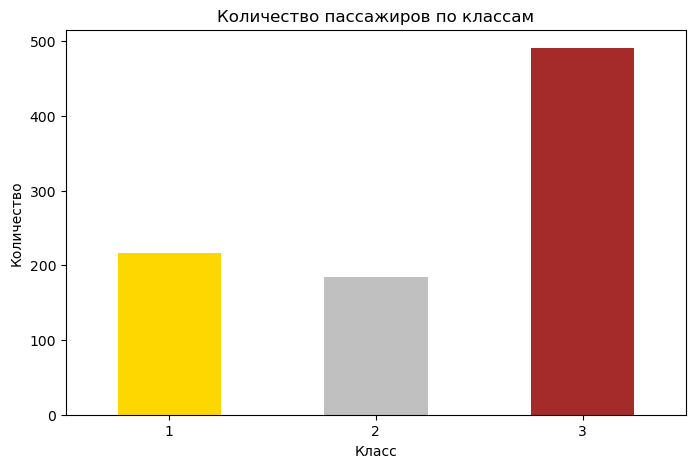

In [33]:
plt.figure(figsize=(8, 5))
df['Pclass'].value_counts().sort_index().plot(kind='bar', color=['gold', 'silver', 'brown'])
plt.title('Количество пассажиров по классам')
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.show()

График выживаемости по полу

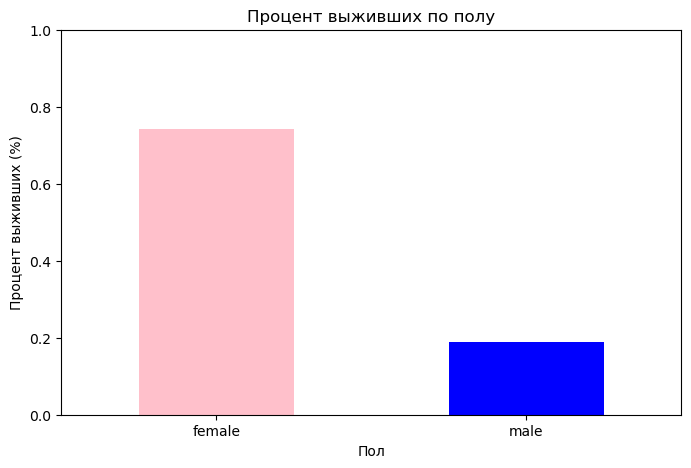

In [35]:
plt.figure(figsize=(8, 5))
df.groupby('Sex')['Survived'].mean().plot(kind='bar', color=['pink', 'blue'])
plt.title('Процент выживших по полу')
plt.xlabel('Пол')
plt.ylabel('Процент выживших (%)')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.show()

### Собственный вопрос к данным

В каком классе доля выживших была наибольшей?

In [41]:
print(df.groupby('Pclass')['Survived'].mean() * 100)
print(f"Класс с наибольшей долей выживших: {df.groupby('Pclass')['Survived'].mean().idxmax()}")

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64
Класс с наибольшей долей выживших: 1
